In [8]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np


Total trading days downloaded: 2514

Checking each ticker for the missing data...
JPM: data starts from 2016-07-25, 0 missing day(s) in the window
BAC: data starts from 2016-07-25, 0 missing day(s) in the window
WFC: data starts from 2016-07-25, 0 missing day(s) in the window
C: data starts from 2016-07-25, 0 missing day(s) in the window
GS: data starts from 2016-07-25, 0 missing day(s) in the window
MS: data starts from 2016-07-25, 0 missing day(s) in the window
AXP: data starts from 2016-07-25, 0 missing day(s) in the window
BLK: data starts from 2016-07-25, 0 missing day(s) in the window
SCHW: data starts from 2016-07-25, 0 missing day(s) in the window
USB: data starts from 2016-07-25, 0 missing day(s) in the window


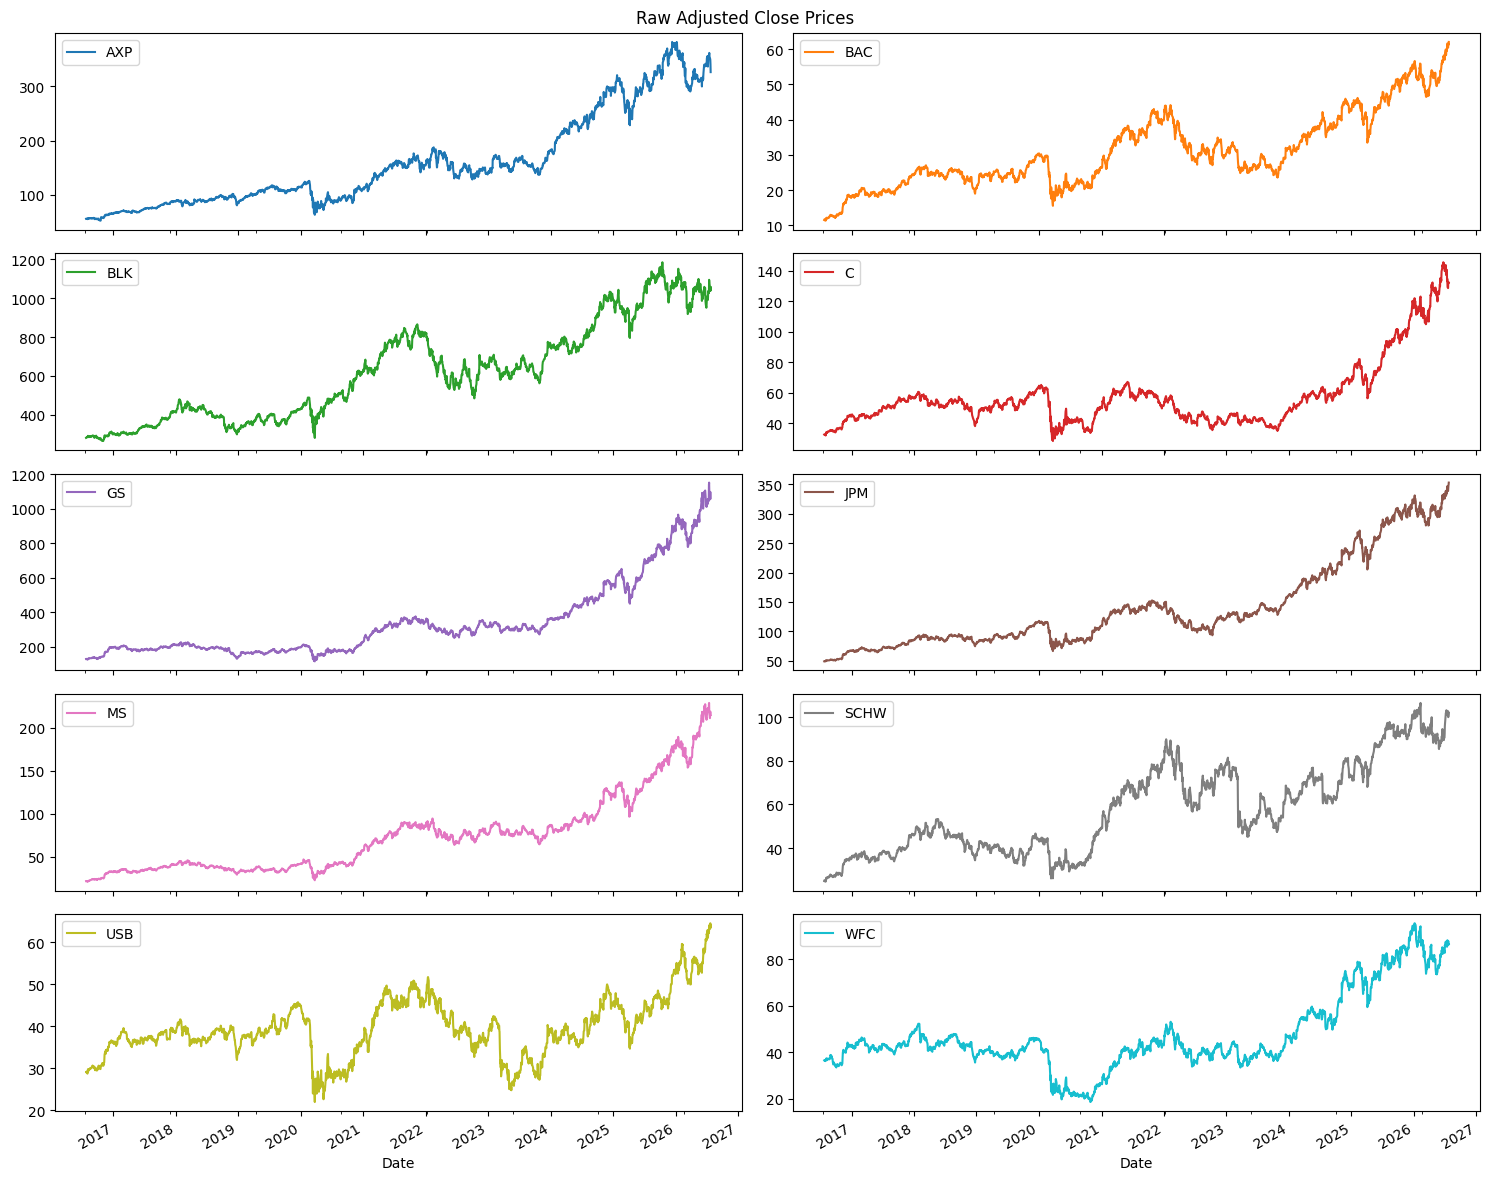

In [9]:

# =====================================================
# Phase 1: Data Collection
# =====================================================

# Defining equity universe and benchmark[Banking & Financial Services]
tickers = [
    'JPM', 'BAC', 'WFC', 'C', 'GS',
    'MS', 'AXP', 'BLK', 'SCHW', 'USB'
]

benchmark = '^GSPC'   # S&P 500

start_date = '2016-07-25'
end_date = '2026-07-25'

# Downloading the prices
print("Downloading portfolio prices...")

portfolio_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

prices = portfolio_data['Adj Close']

# Downloading the benchmark as a one-item list
print("Downloading benchmark prices...")

benchmark_data = yf.download(
    [benchmark],
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

benchmark_prices = benchmark_data['Adj Close'][benchmark]
benchmark_prices.name = 'S&P 500'

# Aligning each stock to the benchmark's trading calendar
prices = prices.reindex(benchmark_prices.index)

# =====================================================
# Basic Checks
# =====================================================

print(f"\nTotal trading days downloaded: {len(prices)}")
print("\nChecking each ticker for the missing data...")

for ticker in tickers:
    ticker_prices = prices[ticker]

    if ticker_prices.isna().all():
        print(f"{ticker}: No data at all")
        continue

    first_date = ticker_prices.dropna().index.min()
    n_missing = ticker_prices.isna().sum()

    print(
        f"{ticker}: data starts from {first_date.date()}, "
        f"{n_missing} missing day(s) in the window"
    )

# =====================================================
# Looking at prices visually
# =====================================================

prices.plot(
    subplots=True,
    layout=(5, 2),
    figsize=(15, 12),
    title='Raw Adjusted Close Prices'
)

plt.tight_layout()
plt.show()

In [11]:
prices.to_csv("C:\\Users\\mahav\\Downloads\\QFI Assignment\\Raw_Portfolio_Prices.csv")
benchmark_prices.to_csv('Benchmark_prices_1.csv')

In [10]:
print(prices.head())
print(benchmark_prices.head())

Ticker            AXP        BAC         BLK          C          GS  \
Date                                                                  
2016-07-25  56.060959  11.500013  282.349823  32.647011  130.650314   
2016-07-26  56.095814  11.628059  282.748199  32.728539  131.179337   
2016-07-27  56.287540  11.708084  283.826355  32.832333  131.041000   
2016-07-28  56.461845  11.748098  283.873199  32.795120  130.666565   
2016-07-29  56.174255  11.596045  286.123169  32.594254  129.266571   

Ticker            JPM         MS       SCHW        USB        WFC  
Date                                                               
2016-07-25  49.110905  21.956348  24.876661  29.051012  36.456257  
2016-07-26  49.310825  22.031713  25.219967  29.051012  36.342617  
2016-07-27  49.464615  22.024126  25.272785  29.078701  36.365341  
2016-07-28  49.287758  21.902699  25.272785  29.127161  36.463829  
2016-07-29  49.187798  21.804041  25.017494  29.189445  36.342617  
Date
2016-07-25    2168.47